# Chladni01

The program calculates a solution for a vibrating, circular disk by solving 
the corresponding stationary partial differential equation.


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh

## Parameters

In [2]:
rho = 0.95                       # Density in kg/dm^3
mu  = 1e3                        # Torsionsmodul in N/dm^2

## Create solution object and define geometry

In [3]:
# discretize the domain using a grid and mask the circular region
N = 400  # Grid resolution
x = np.linspace(-1.1, 1.1, N)
y = np.linspace(-1.1, 1.1, N)
X, Y = np.meshgrid(x, y)
h = x[1] - x[0]

# Mask for the circular disk (radius = 1)
mask = (X**2 + Y**2 <= 1.0)
interior_indices = np.where(mask.flatten())[0]
num_interior = len(interior_indices)

# Mapping from global grid to interior points
id_map = -np.ones(N*N, dtype=int)
id_map[interior_indices] = np.arange(num_interior)

## Solve the PDE
We solve the eigenvalue problem for the Laplacian operator with Dirichlet boundary conditions:
$$\mu \nabla^2 u + \lambda \rho u = 0 \implies -\nabla^2 u = \frac{\rho}{\mu} \lambda u$$
Boundary condition: $u(x,y) = 0$ for $x^2 + y^2 = 1$.

In [4]:
# Solving the partial differential equation

# Construct the sparse Laplacian matrix (5-point stencil)
A = lil_matrix((num_interior, num_interior))

for idx in interior_indices:
    i, j = divmod(idx, N)
    row = id_map[idx]
    
    # Standard finite difference for Laplacian: (u_up + u_down + u_left + u_right - 4*u_center) / h^2
    A[row, row] = -4 / h**2
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        ni, nj = i + di, j + dj
        neighbor_idx = ni * N + nj
        if 0 <= ni < N and 0 <= nj < N and id_map[neighbor_idx] != -1:
            A[row, id_map[neighbor_idx]] = 1 / h**2

# Matrix for the eigenvalue problem: -mu * Laplacian * u = lambda * rho * u
# Equivalent to: Laplacian * u = - (rho * lambda / mu) * u
# Let L = -A. Then L * u = k * u, where k = (rho * lambda / mu)
L = -A

# Calculate first 6 eigenvalues and eigenvectors
# 'sm' finds the smallest eigenvalues (lowest frequencies)
k_vals, u_vecs = eigsh(L, k=6, which='SM')

# Convert back to lambda (eigenvalues)
eigenvalues = k_vals * mu / rho

## Visualization

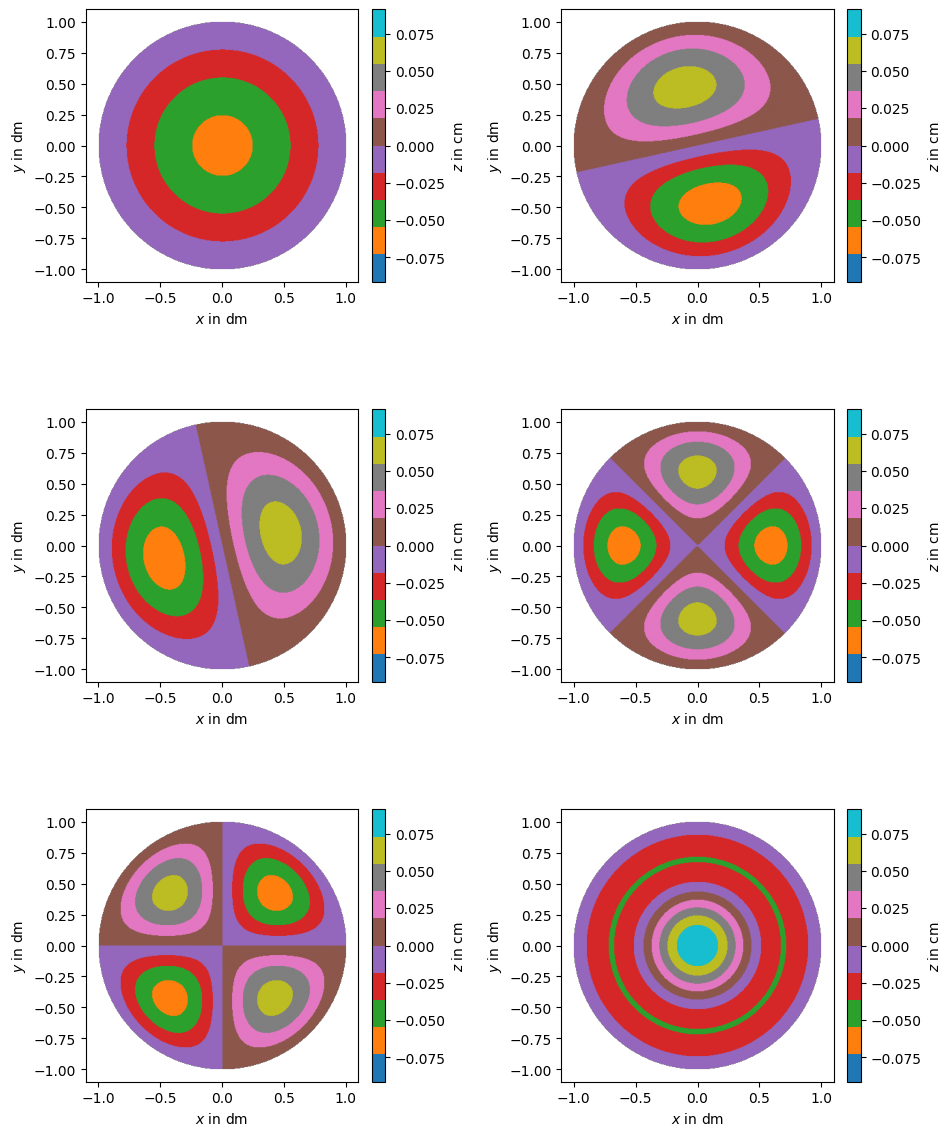

In [5]:
# Build full-grid modes from reduced eigenvectors (FD result u_vecs)
# u_vecs shape: (num_interior, 6)  (from eigsh)
# interior_indices: indices in flattened N*N grid that belong to the disk

# Create full flattened array and fill interior values
num_modes = u_vecs.shape[1]
full_flat = np.zeros((N*N, num_modes))
full_flat[interior_indices, :] = u_vecs

# Reshape to (N, N, num_modes) for plotting
modes_grid = full_flat.reshape((N, N, num_modes))

# Scaling and color limits
scale = 10.0  
# automatic symmetric limit based on all plotted modes:
global_max = np.max(np.abs(modes_grid)) * scale
vmax = global_max
vmin = -vmax

# Plot first six modes on the regular grid with a shared colorbar
cmap = plt.get_cmap('tab10')
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.ravel()

# extent for imshow: [xmin, xmax, ymin, ymax]
extent = [x.min(), x.max(), y.min(), y.max()]

for i in range(6):
    ax = axes[i]
    U = modes_grid[:, :, i] * scale  # apply visualization scaling
    # mask outside disk for nicer plotting
    U_masked = np.ma.array(U, mask=~mask)
    im = ax.imshow(U_masked, origin='lower', extent=extent, cmap=cmap, norm=norm)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_xlabel('$\\it x$ in dm')
    ax.set_ylabel('$\\it y$ in dm')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('$\\it z$ in cm')

plt.tight_layout(pad=3.0, w_pad=2.5, h_pad=6.0)
plt.show()

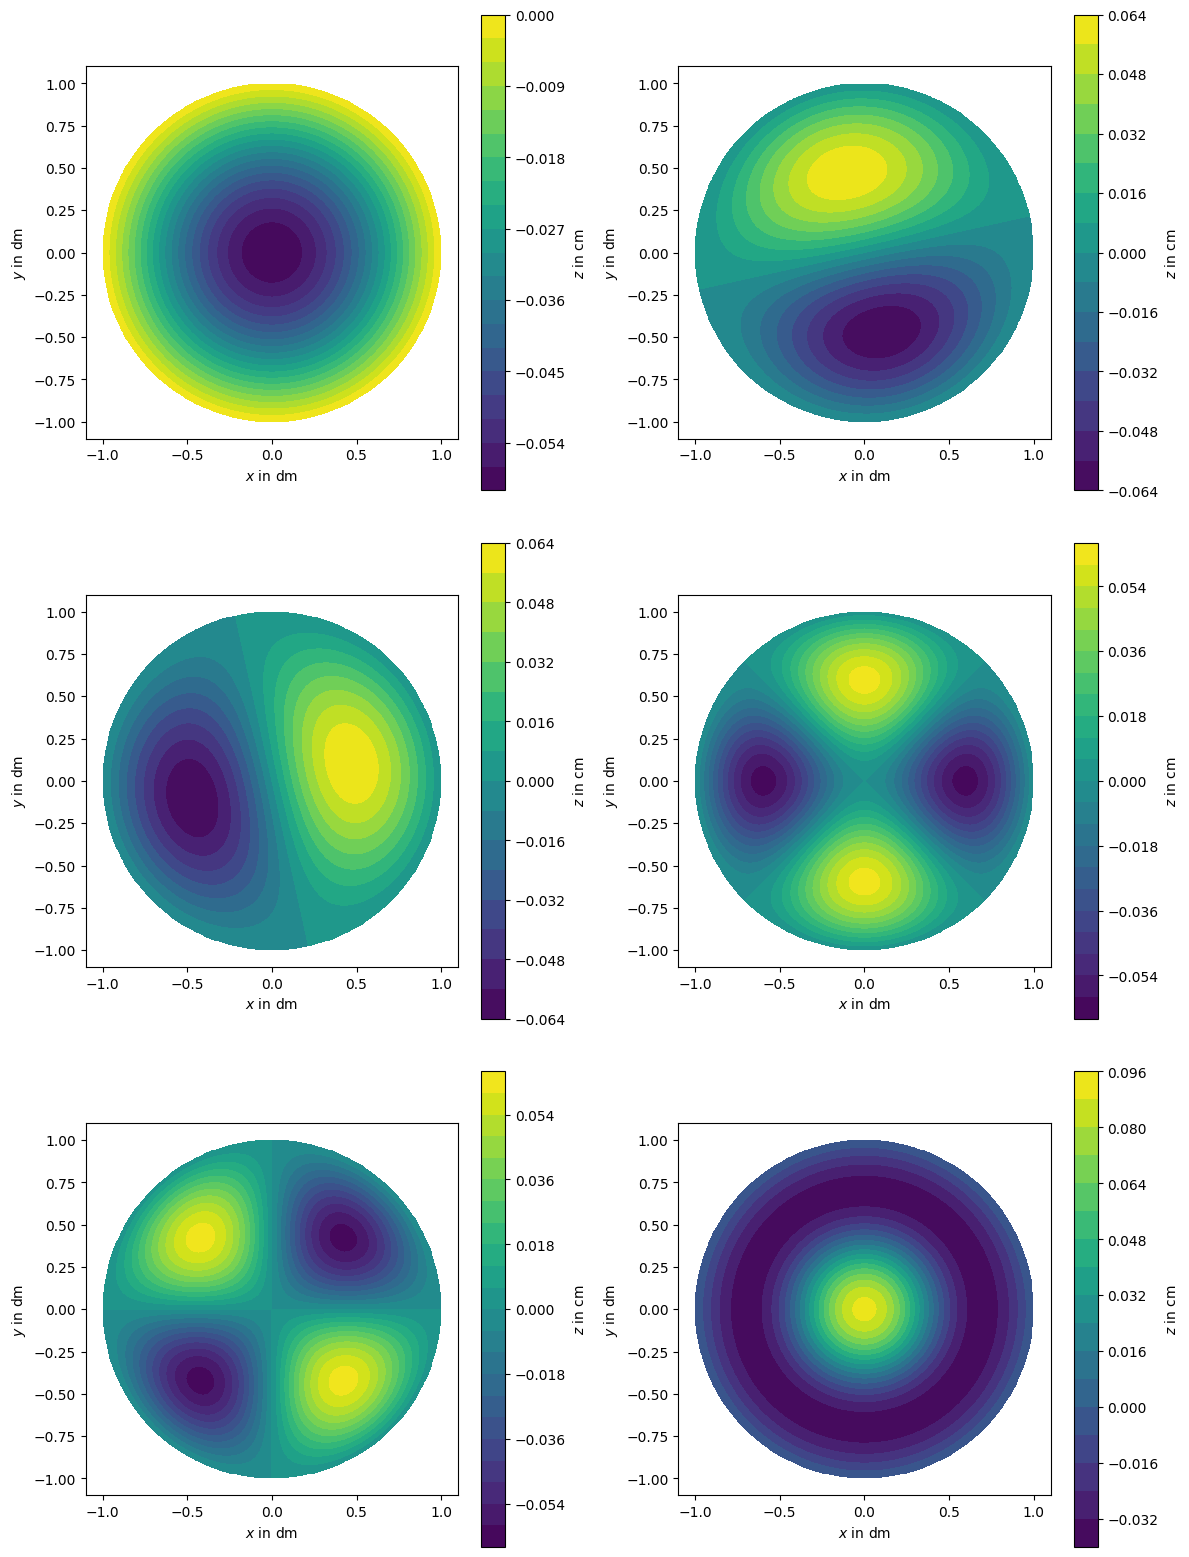

In [6]:
# Visualization without change color
fig = plt.figure(figsize=(12, 16))

for i in range(6):
    ax = fig.add_subplot(3, 2, i+1)
    
    u_grid = np.zeros(N*N)
    u_grid[interior_indices] = u_vecs[:, i]
    U = u_grid.reshape((N, N))
    cont = ax.contourf(X, Y, np.where(mask, U * 10, np.nan), levels=20, cmap='viridis')
    
    ax.set_aspect('equal')
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_xlabel("$\\mathit{x}$ in dm")
    ax.set_ylabel("$\\mathit{y}$ in dm")
    
    cbar = fig.colorbar(cont, ax=ax)
    cbar.set_label("$\\mathit{z}$ in cm")
    
plt.tight_layout()
plt.show()